In this notebook, we apply all filters to the KITTI raw dataset sequence number 04 in different setups:
* Setup1: IMU, VO
* Setup2: IMU, VO + GPS
* Setup3: INS, VO + GPS

In [1]:
import os
import sys
import numpy as np
sys.path.append('/app/src')
from data_loader import DataLoader
from configs.configs import FilterEnum, SetupEnum, NoiseTypeEnum, MeasurementDataEnum
from kalman_filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    EnsembleKalmanFilter,
    CubatureKalmanFilter
)

%matplotlib inline
np.random.seed(777)

# Load data sequence 04 (0016)

Data size: 271
Shape:
GPS: (271, 3)
VO: (271, 3)
IMU: (271, 6)
INS angle: (271, 3)
INS velocity: (271, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


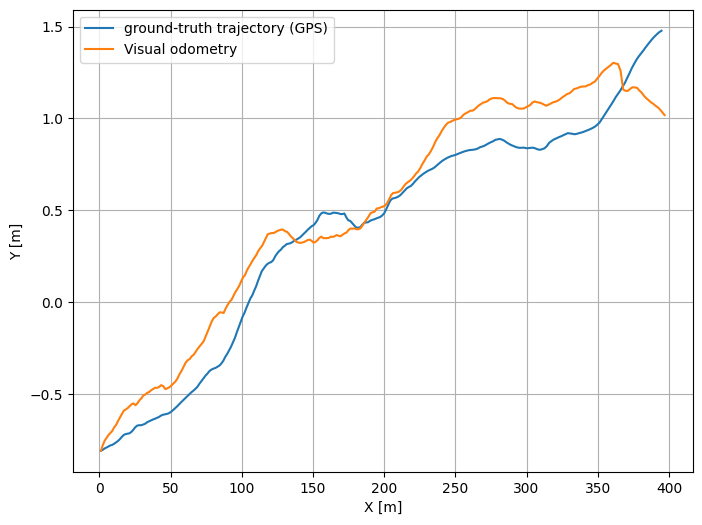

In [2]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0016'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0.0, 
                  gps_dropout_ratio=0.0)

## Display data with noise

### VO trajectory with noise

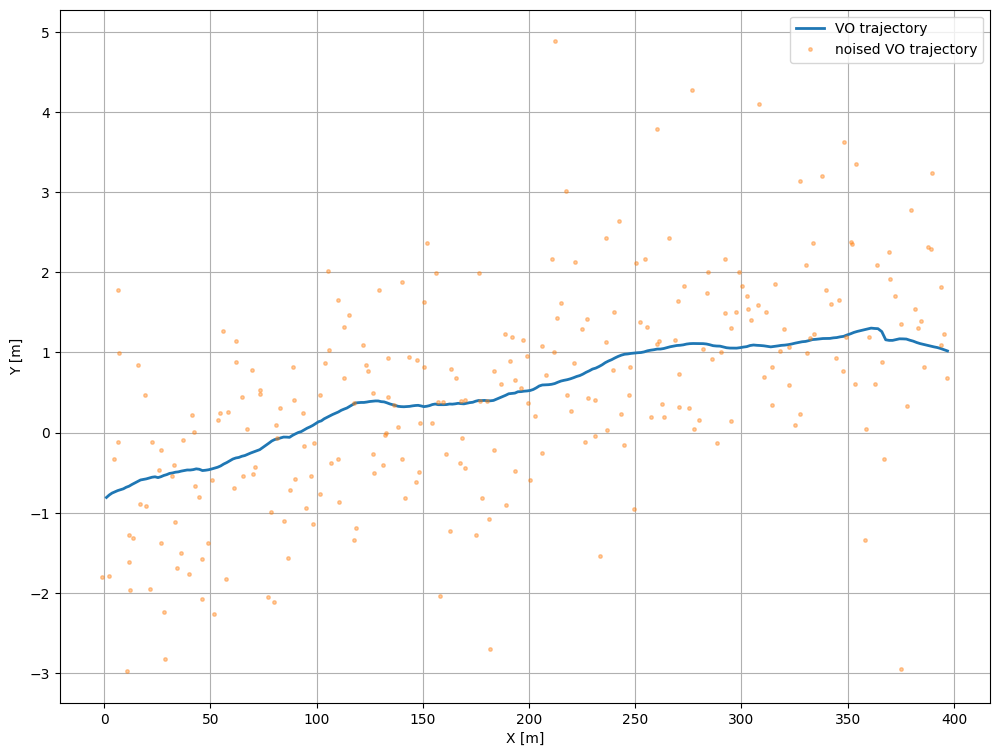

In [3]:
data.show_vo_with_noise()

### Linear acceleration with noise

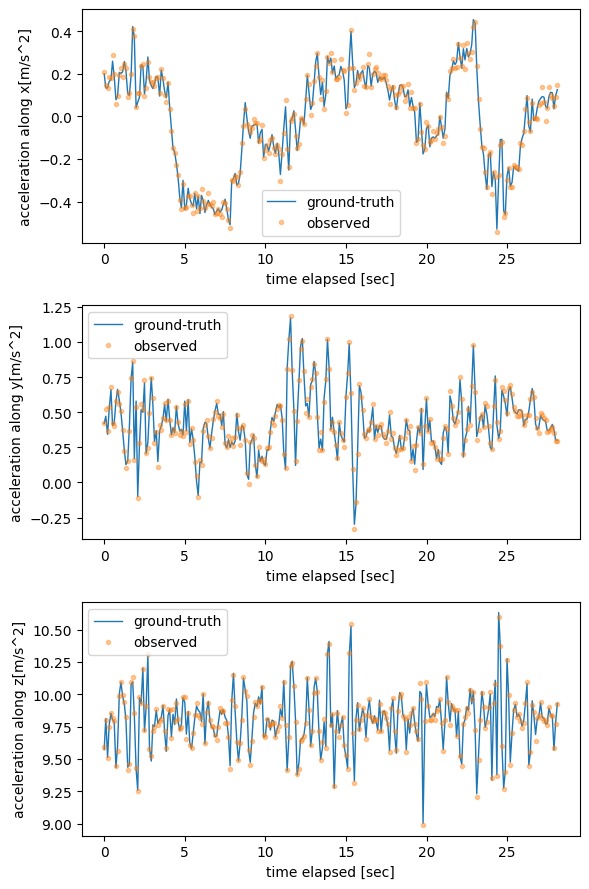

In [4]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

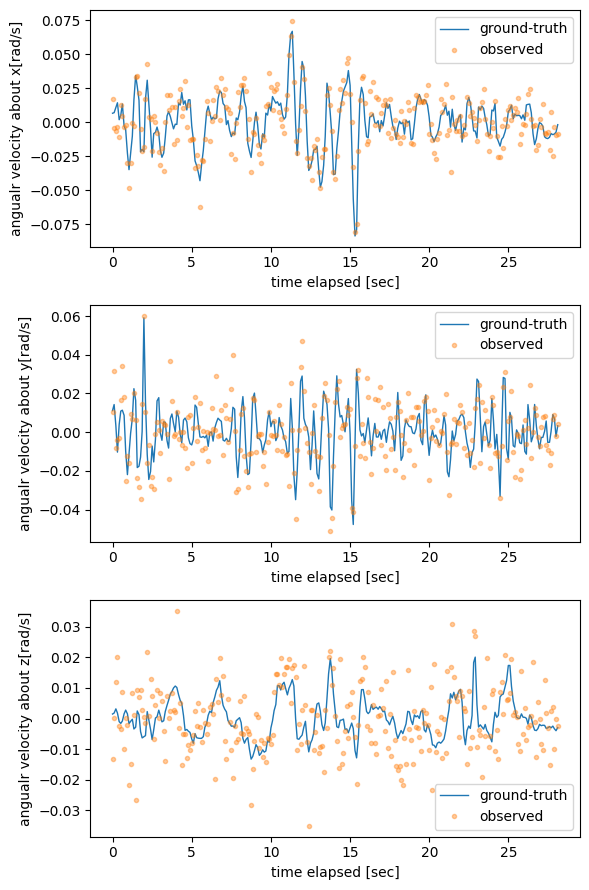

In [5]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

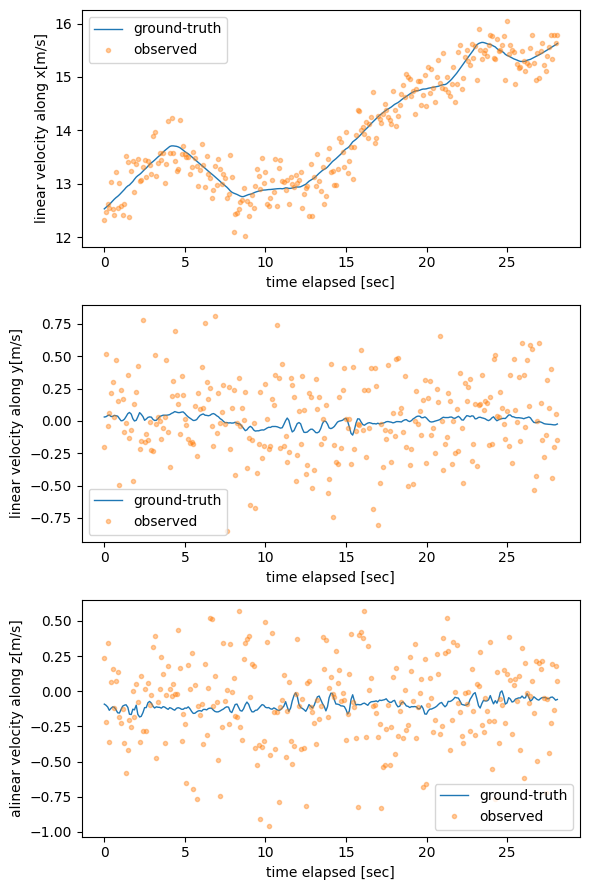

In [6]:
data.show_linear_velocity_with_noise()

# Filter Test

## Filter parameters

In [44]:
alpha_setup1_0 = 1.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

alpha_setup2_0 = 0.6
beta_setup2_0 = 2.0
kappa_setup2_0 = 0.0

alpha_setup3_0 = 0.0001
beta_setup3_0 = 2.0
kappa_setup3_0 = 0.0

n_samples_setup1_0 = 2048
resampling_algorithm_setup1_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup2_0 = 2048
resampling_algorithm_setup2_0 = ResamplingAlgorithms.STRATIFIED
n_samples_setup3_0 = 2048
resampling_algorithm_setup3_0 = ResamplingAlgorithms.RESIDUAL

importance_resampling = True

n_ensemble_setup1_0 = 64
n_ensemble_setup2_0 = 64
n_ensemble_setup3_0 = 64


## Setup configs

In [45]:
noise_type = NoiseTypeEnum.CURRENT
measurement_type = MeasurementDataEnum.ALL_DATA
debug_mode = True
show_graph = True

In [46]:
lim_min = np.min(data.GPS_measurements_in_meter.T[:2, :], axis=1)
lim_max = np.max(data.GPS_measurements_in_meter.T[:2, :], axis=1)
lim_std = np.std(data.GPS_measurements_in_meter.T[:2, :], axis=1)

max_variance_index = np.argmax(lim_std)
square_lim = [lim_min[max_variance_index] - lim_std[max_variance_index], 
              lim_max[max_variance_index] + lim_std[max_variance_index]]
lim_min_margin = lim_min - lim_std
lim_max_margin = lim_max + lim_std
xlim = [lim_min_margin[0], lim_max_margin[0]]
ylim = [lim_min_margin[1], lim_max_margin[1]]

# Setup1 (IMU, VO)

In [47]:
setup = SetupEnum.SETUP_1

## Extended Kalman Filter (EKF)

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 7987.52it/s]


----- [EKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.726 m
Root Mean Squared Error: 0.976 m
Maximum Error: 3.631 m
---------------------------------------------------



{<ErrorEnum.MAE: 1>: 0.726,
 <ErrorEnum.RMSE: 2>: 0.976,
 <ErrorEnum.MAX: 3>: 3.631}

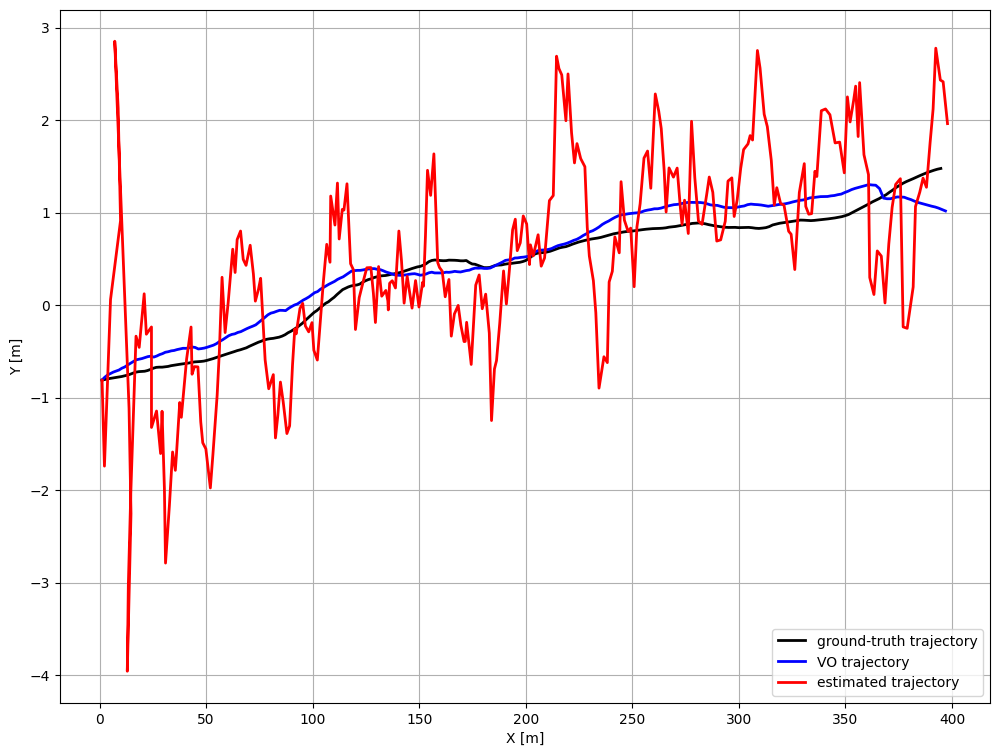

In [48]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)

ekf1_0 = ExtendedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)

ekf1_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## Unscented Kalman Filter (UKF)

[UKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2264.36it/s]


----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.525 m
Root Mean Squared Error: 1.865 m
Maximum Error: 5.344 m
---------------------------------------------------



{<ErrorEnum.MAE: 1>: 1.525,
 <ErrorEnum.RMSE: 2>: 1.865,
 <ErrorEnum.MAX: 3>: 5.344}

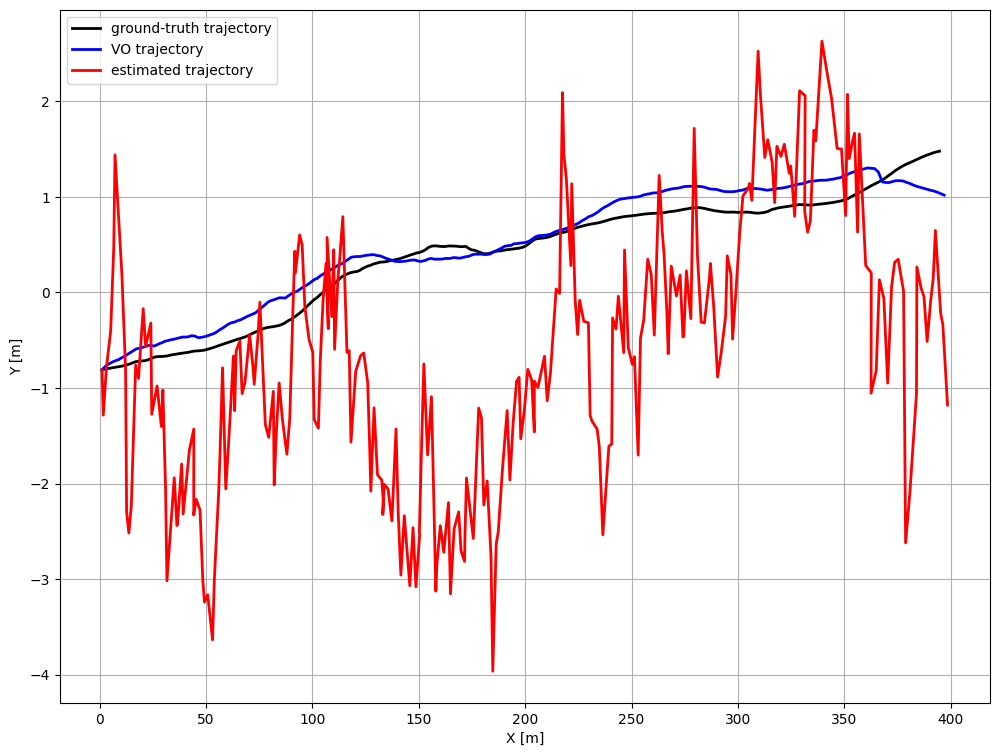

In [50]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type)

ukf1_0 = UnscentedKalmanFilter(
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  alpha=alpha_setup1_0, 
  beta=beta_setup1_0, 
  kappa=kappa_setup1_0,
  setup=setup
)

ukf1_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## Particle Filter (PF)

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:11<00:00, 24.16it/s]


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.994 m
Root Mean Squared Error: 1.516 m
Maximum Error: 7.279 m
--------------------------------------------------



{<ErrorEnum.MAE: 1>: 0.994,
 <ErrorEnum.RMSE: 2>: 1.516,
 <ErrorEnum.MAX: 3>: 7.279}

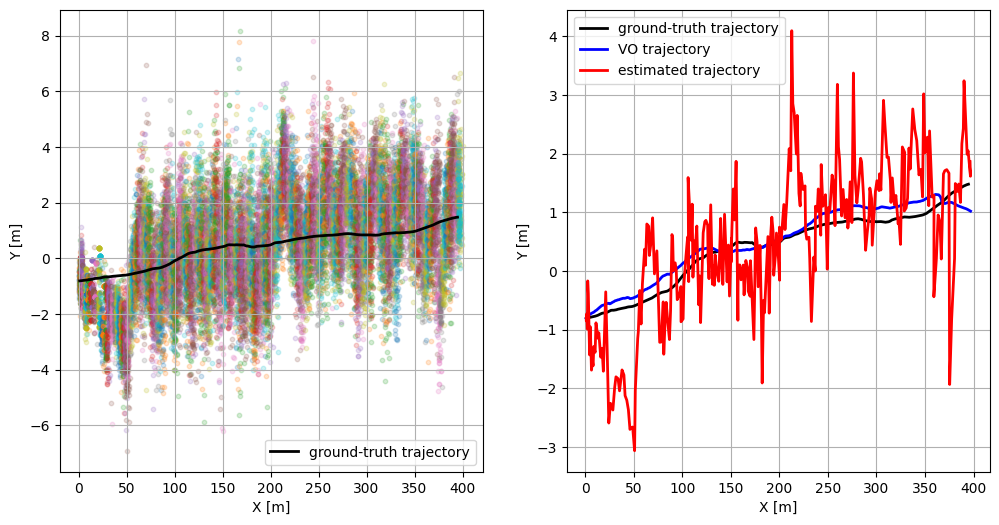

In [52]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf1_0 = ParticleFilter(
  N=n_samples_setup1_0, 
  x_dim=x_setup1.shape[0], 
  H=H_setup1.copy(), 
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup1_0
)
pf1_0.create_gaussian_particles(mean=x_setup1.copy(), var=P_setup1.copy())

pf1_0.run(
    data=data, 
    importance_resampling=importance_resampling,
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## Ensemble Kalman Filter (EnKF)

[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 629.87it/s]


----- [EnKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.131 m
Root Mean Squared Error: 1.442 m
Maximum Error: 5.415 m
----------------------------------------------------



{<ErrorEnum.MAE: 1>: 1.131,
 <ErrorEnum.RMSE: 2>: 1.442,
 <ErrorEnum.MAX: 3>: 5.415}

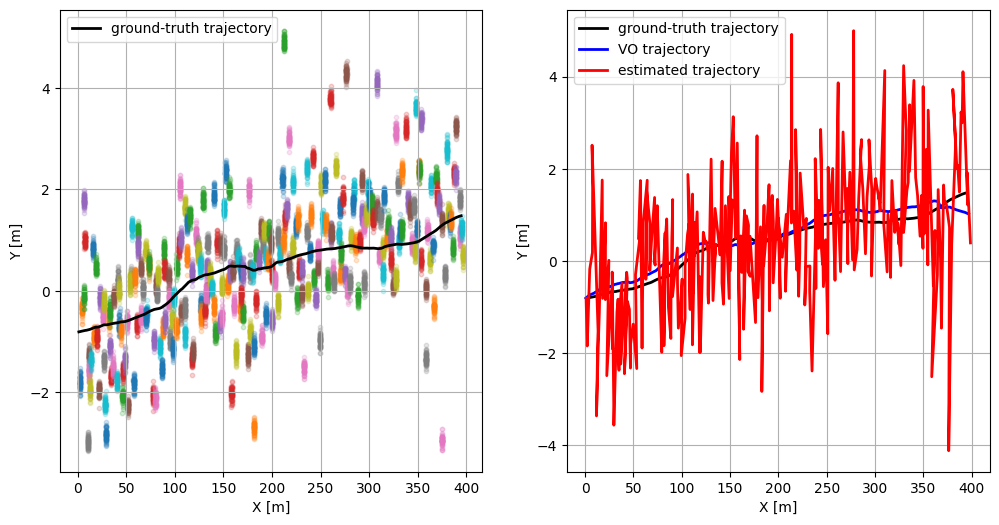

In [13]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)

enkf1_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup1_0, 
  x=x_setup1.copy(), 
  P=P_setup1.copy(), 
  H=H_setup1.copy(),
  q=q1,
  r_vo=r_vo1,
  r_gps=r_gps1,
  setup=setup
)
enkf1_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## Cubature Kalman Filter (CKF)

[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2542.25it/s]


----- [CKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 0.746 m
Root Mean Squared Error: 0.969 m
Maximum Error: 3.75 m
---------------------------------------------------



{<ErrorEnum.MAE: 1>: 0.746,
 <ErrorEnum.RMSE: 2>: 0.969,
 <ErrorEnum.MAX: 3>: 3.75}

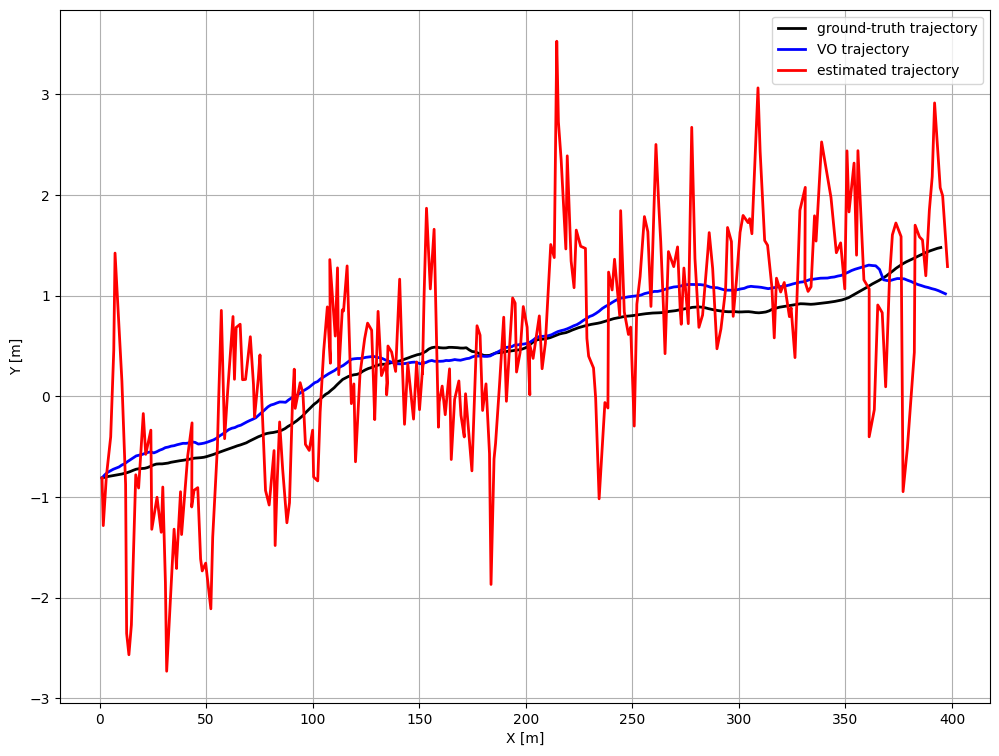

In [15]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
)
ckf1_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

# Setup2 (IMU, VO+GPS)

In [17]:
setup = SetupEnum.SETUP_2

## EKF

[EKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 9259.40it/s]


----- [EKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.515 m
Root Mean Squared Error: 0.679 m
Maximum Error: 3.02 m
-------------------------------------------------------



{<ErrorEnum.MAE: 1>: 0.515,
 <ErrorEnum.RMSE: 2>: 0.679,
 <ErrorEnum.MAX: 3>: 3.02}

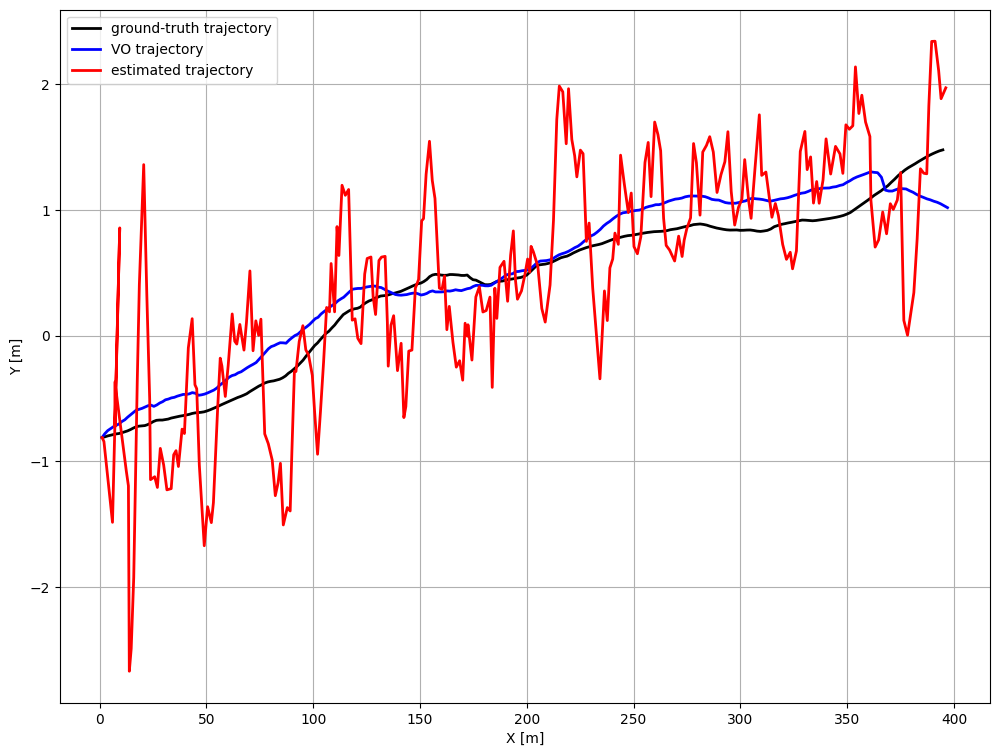

In [18]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)
ekf2_0 = ExtendedKalmanFilter(
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)
ekf2_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## UKF

[UKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 1955.60it/s]


----- [UKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.215 m
Root Mean Squared Error: 1.486 m
Maximum Error: 4.059 m
-------------------------------------------------------



{<ErrorEnum.MAE: 1>: 1.215,
 <ErrorEnum.RMSE: 2>: 1.486,
 <ErrorEnum.MAX: 3>: 4.059}

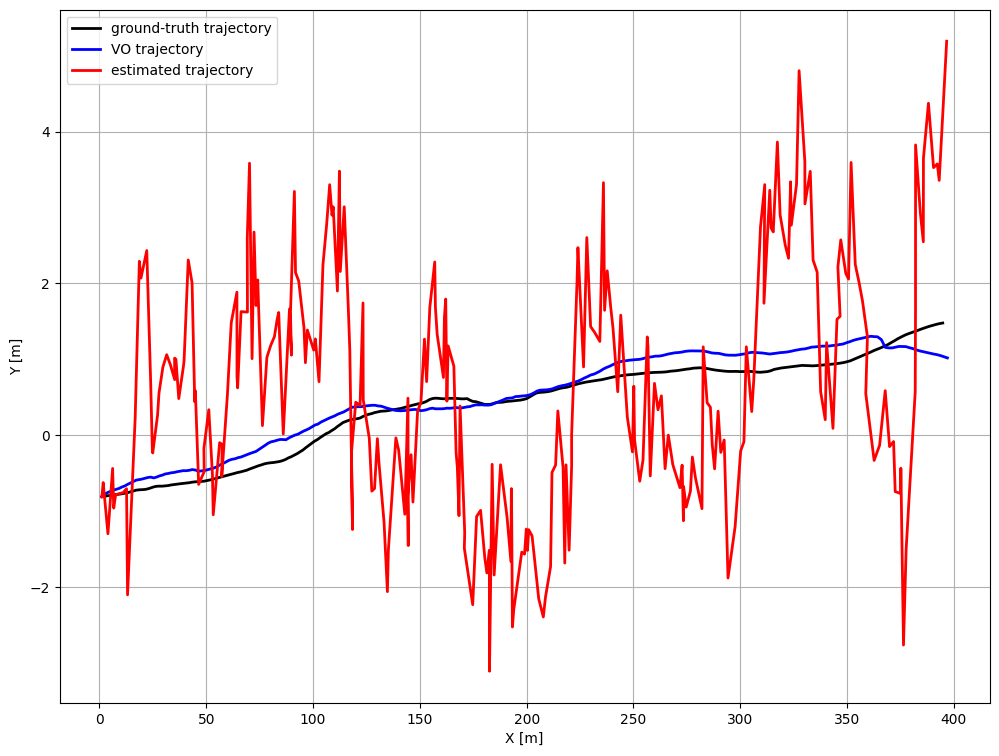

In [20]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type
)

ukf2_0 = UnscentedKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(), 
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    alpha=alpha_setup2_0, 
    beta=beta_setup2_0, 
    kappa=kappa_setup2_0,
    setup=setup
)

ukf2_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## PF

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:18<00:00, 14.99it/s]


----- [PF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.912 m
Root Mean Squared Error: 1.541 m
Maximum Error: 7.188 m
------------------------------------------------------



{<ErrorEnum.MAE: 1>: 0.912,
 <ErrorEnum.RMSE: 2>: 1.541,
 <ErrorEnum.MAX: 3>: 7.188}

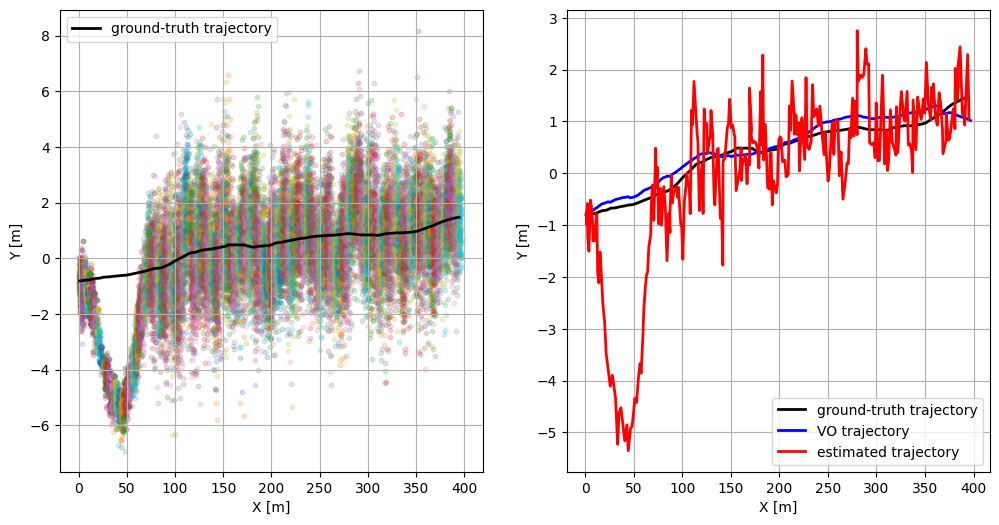

In [22]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)
pf2_0 = ParticleFilter(
  N=n_samples_setup2_0, 
  x_dim=x_setup2.shape[0], 
  H=H_setup2.copy(), 
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup2_0
)
pf2_0.create_gaussian_particles(mean=x_setup2.copy(), var=P_setup2.copy())

pf2_0.run(
    data=data, 
    importance_resampling=importance_resampling,
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## EnKF

[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 547.34it/s]


----- [EnKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 1.069 m
Root Mean Squared Error: 1.371 m
Maximum Error: 4.181 m
--------------------------------------------------------



{<ErrorEnum.MAE: 1>: 1.069,
 <ErrorEnum.RMSE: 2>: 1.371,
 <ErrorEnum.MAX: 3>: 4.181}

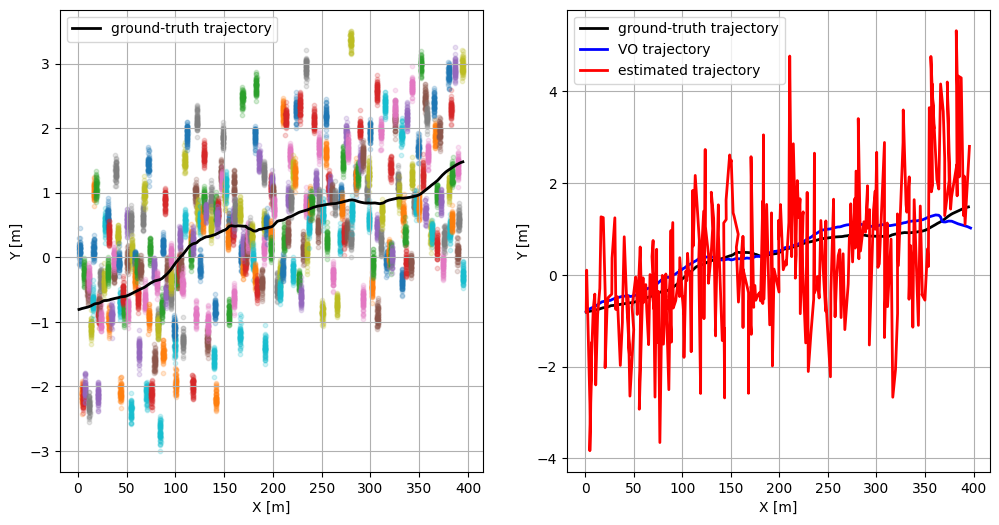

In [24]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)
enkf2_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup2_0, 
  x=x_setup2.copy(), 
  P=P_setup2.copy(), 
  H=H_setup2.copy(),
  q=q2,
  r_vo=r_vo2,
  r_gps=r_gps2,
  setup=setup
)

enkf2_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## CKF

[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 2086.15it/s]


----- [CKF] Error report for Setup2 (IMU, VO+GPS) -----
Mean Absolute Error: 0.609 m
Root Mean Squared Error: 0.783 m
Maximum Error: 3.865 m
-------------------------------------------------------



{<ErrorEnum.MAE: 1>: 0.609,
 <ErrorEnum.RMSE: 2>: 0.783,
 <ErrorEnum.MAX: 3>: 3.865}

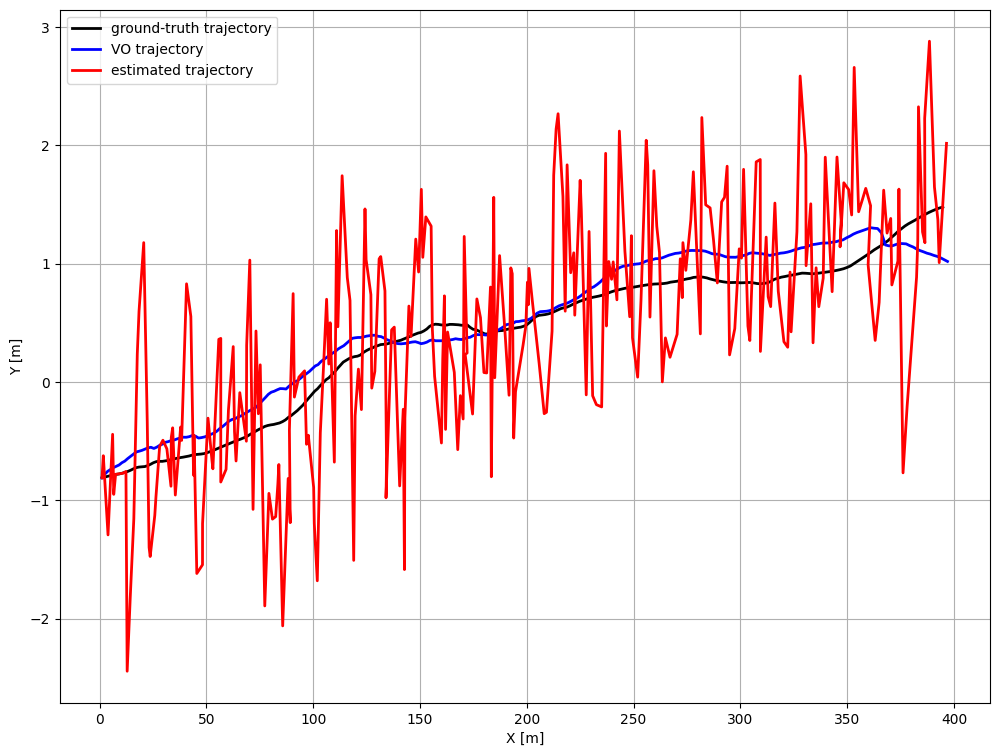

In [26]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.CKF, 
  noise_type=noise_type)

ckf2_0 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
)
ckf2_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

# Setup3 (INS)

In [28]:
setup = SetupEnum.SETUP_3

## EKF

[EKF] start.


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 14394.73it/s]


----- [EKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.383 m
Root Mean Squared Error: 0.503 m
Maximum Error: 1.614 m
-----------------------------------------------



{<ErrorEnum.MAE: 1>: 0.383,
 <ErrorEnum.RMSE: 2>: 0.503,
 <ErrorEnum.MAX: 3>: 1.614}

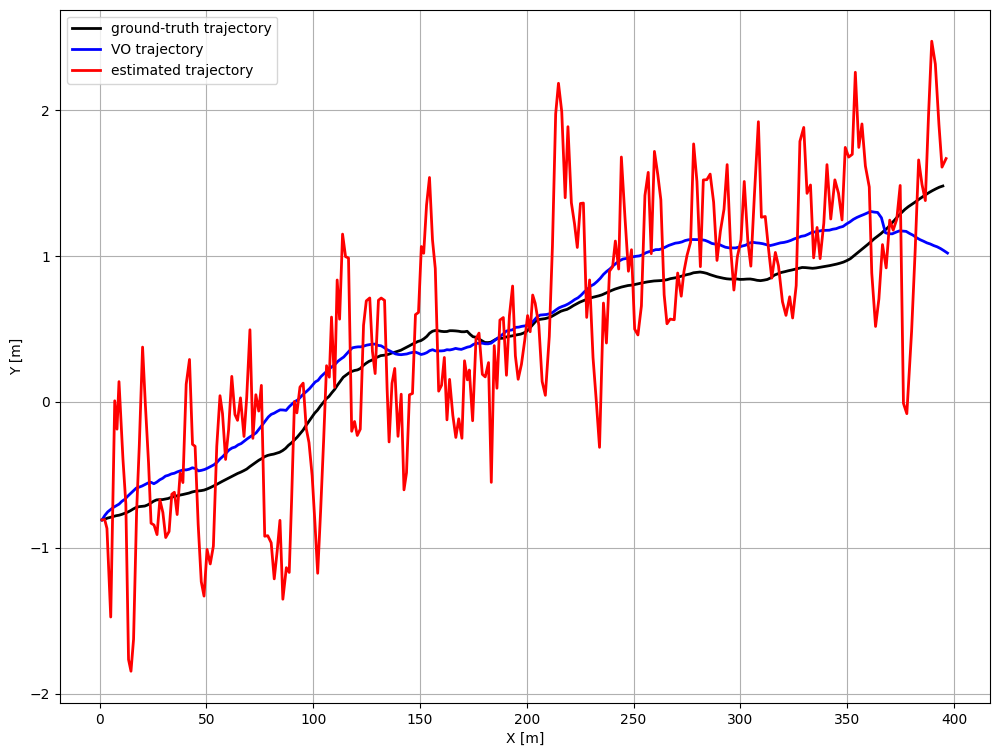

In [29]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EKF, 
  noise_type=noise_type)

ekf3_0 = ExtendedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

ekf3_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## UKF

[UKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6170.72it/s]


----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.53 m
Root Mean Squared Error: 0.681 m
Maximum Error: 2.993 m
-----------------------------------------------



{<ErrorEnum.MAE: 1>: 0.53,
 <ErrorEnum.RMSE: 2>: 0.681,
 <ErrorEnum.MAX: 3>: 2.993}

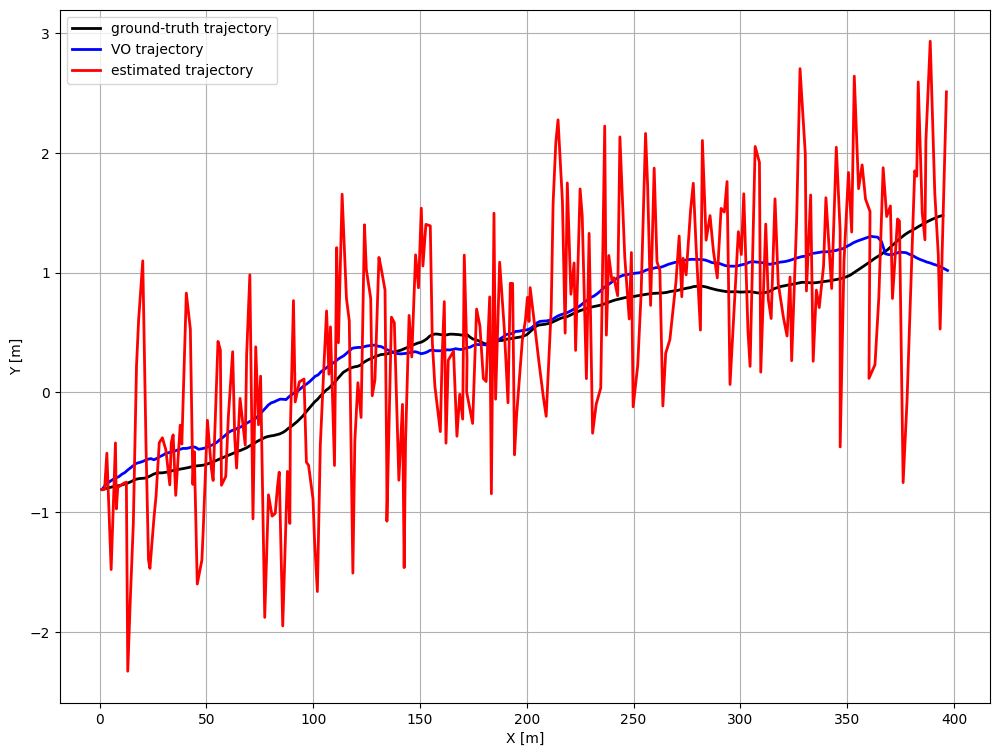

In [31]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.UKF, 
  noise_type=noise_type
)

ukf3_0 = UnscentedKalmanFilter(
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  alpha=alpha_setup3_0, 
  beta=beta_setup3_0, 
  kappa=kappa_setup3_0,
  setup=setup,
)

ukf3_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## PF

[PF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:11<00:00, 23.62it/s]


----- [PF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 1.028 m
Root Mean Squared Error: 1.448 m
Maximum Error: 5.809 m
--------------------------------------------------



{<ErrorEnum.MAE: 1>: 1.028,
 <ErrorEnum.RMSE: 2>: 1.448,
 <ErrorEnum.MAX: 3>: 5.809}

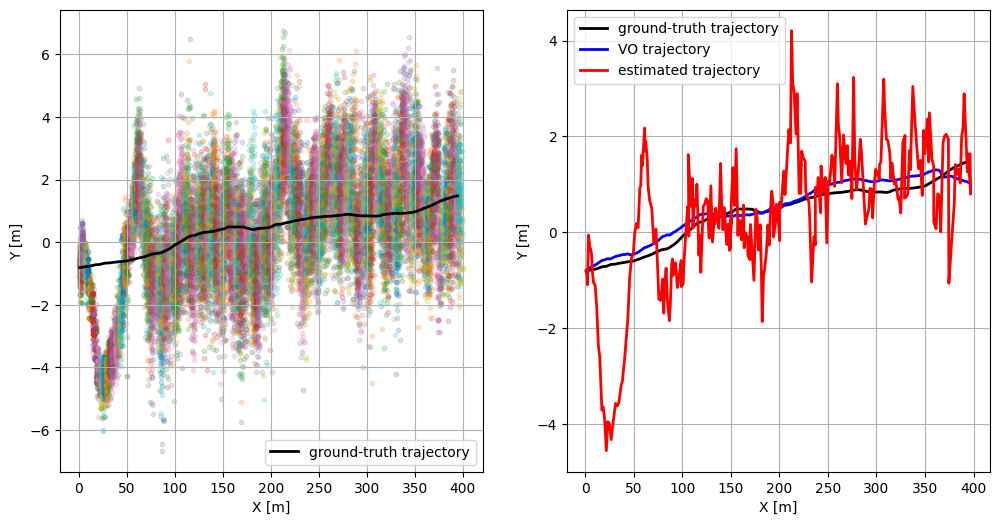

In [54]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.PF, 
  noise_type=noise_type)

pf3_0 = ParticleFilter(
  N=n_samples_setup3_0, 
  x_dim=x_setup3.shape[0], 
  H=H_setup3.copy(), 
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
  resampling_algorithm=resampling_algorithm_setup3_0
)
pf3_0.create_gaussian_particles(mean=x_setup3.copy(), var=P_setup3.copy())

pf3_0.run(
    data=data, 
    importance_resampling=importance_resampling,
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## EnKF

[EnKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 777.67it/s]


----- [EnKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.982 m
Root Mean Squared Error: 1.242 m
Maximum Error: 3.881 m
------------------------------------------------



{<ErrorEnum.MAE: 1>: 0.982,
 <ErrorEnum.RMSE: 2>: 1.242,
 <ErrorEnum.MAX: 3>: 3.881}

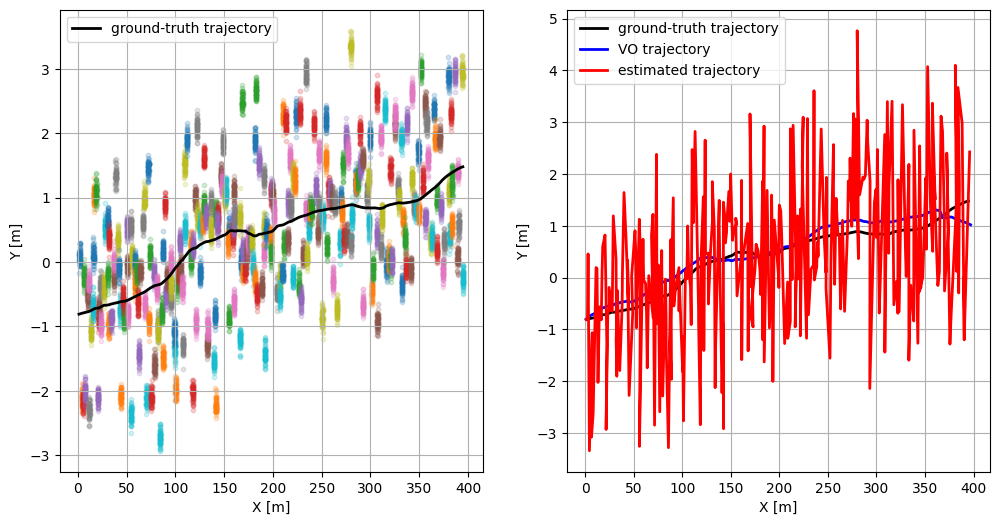

In [35]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)

enkf3_0 = EnsembleKalmanFilter(
  N=n_ensemble_setup3_0, 
  x=x_setup3.copy(), 
  P=P_setup3.copy(), 
  H=H_setup3.copy(),
  q=q3,
  r_vo=r_vo3,
  r_gps=r_gps3,
  setup=setup,
)

enkf3_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)

## CKF

[CKF] start.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 270/270 [00:00<00:00, 6796.23it/s]


----- [CKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 0.521 m
Root Mean Squared Error: 0.671 m
Maximum Error: 2.941 m
-----------------------------------------------



{<ErrorEnum.MAE: 1>: 0.521,
 <ErrorEnum.RMSE: 2>: 0.671,
 <ErrorEnum.MAX: 3>: 2.941}

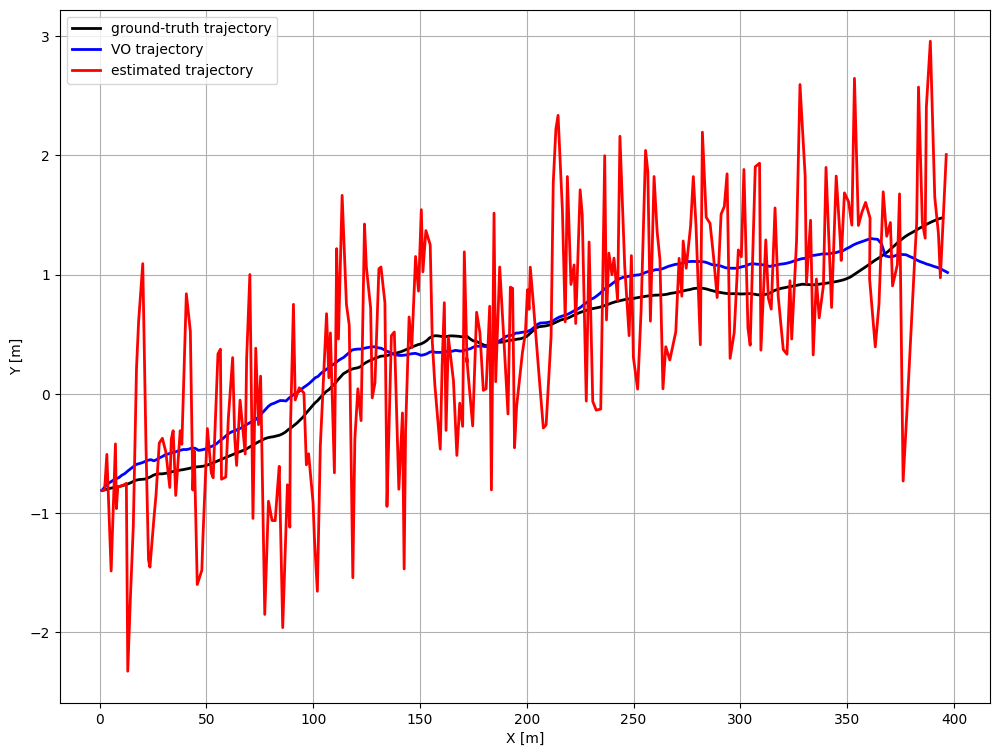

In [37]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=setup, 
  filter_type=FilterEnum.EnKF, 
  noise_type=noise_type)

ckf3_0 = CubatureKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
)
ckf3_0.run(
    data=data, 
    measurement_type=measurement_type, 
    debug_mode=debug_mode,
    show_graph=show_graph,
)